In [1]:
!pip install numpy
!pip install pandas 

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 80000

# ----------------------- PERFORMANCE FEATURES ---------------------
processor_speed = np.random.uniform(1.5, 3.5, n_samples)  # GHz
ram_size = np.random.choice([4, 6, 8, 12, 16], n_samples, p=[0.25, 0.25, 0.25, 0.15, 0.10])
storage_capacity = np.random.choice([64, 128, 256, 512, 1024], n_samples, p=[0.25, 0.3, 0.25, 0.15, 0.05])
battery_capacity = np.random.uniform(3000, 6000, n_samples)

# -------------------------- DISPLAY & CONNECTIVITY -------------------------------------
display_tech = np.random.choice(['LCD', 'AMOLED', 'OLED'], n_samples, p=[0.4, 0.4, 0.2])
display_map = {'LCD': 1, 'AMOLED': 2, 'OLED': 3}
display_encoded = np.array([display_map[d] for d in display_tech])

connectivity = np.random.choice(['4G', '5G'], n_samples, p=[0.4, 0.6])
connectivity_map = {'4G': 1, '5G': 2}
connectivity_encoded = np.array([connectivity_map[c] for c in connectivity])

# ---------------- CAMERA & SOFTWARE SUPPORT ----------------
camera_score = np.random.uniform(4, 10, n_samples)
update_support = np.random.choice([2, 3, 4, 5, 6, 7, 8], n_samples, p=[0.1, 0.15, 0.2, 0.2, 0.15, 0.1, 0.1])
security_updates = np.random.choice([1, 2, 3, 4], n_samples, p=[0.2, 0.4, 0.3, 0.1])

# ---------------- MARKET & BRAND ----------------
brand_score = np.random.uniform(4, 10, n_samples)
release_year = np.random.randint(2015, 2026, n_samples)
initial_price = np.random.uniform(150, 1500, n_samples)
resale_value = initial_price * np.random.uniform(0.4, 0.9, n_samples)
customer_rating = np.random.uniform(2.5, 5.0, n_samples)
depreciation_rate = np.random.uniform(10, 40, n_samples)

# ---------------- TARGET: OBSOLESCENCE TIME (YEARS) ----------------
obsolescence_time = (
    1.5 * (processor_speed / 3.5)
    + 1.3 * (ram_size / 16)
    + 1.1 * (storage_capacity / 512)
    + 1.0 * (battery_capacity / 6000)
    + 0.6 * (display_encoded / 3)
    + 0.9 * (connectivity_encoded / 2)
    + 1.0 * (camera_score / 10)
    + 1.4 * (update_support / 8)
    + 0.9 * (security_updates / 4)
    + 1.0 * (brand_score / 10)
    + 0.7 * (customer_rating / 5)
    + 0.8 * (resale_value / 1500)
    - 0.8 * (depreciation_rate / 40)
    - 0.6 * ((2025 - release_year) / 10)
)

# Normalize to range [1, 10]
obsolescence_time = 1 + 9 * (obsolescence_time - obsolescence_time.min()) / (obsolescence_time.max() - obsolescence_time.min())

# Add small noise for realism
obsolescence_time += np.random.normal(0, 0.35, n_samples)
obsolescence_time = np.clip(obsolescence_time, 1, 10)

# ---------------- CLASSIFICATION LABEL ----------------
conditions = [
    (obsolescence_time >= 8),
    (obsolescence_time >= 6) & (obsolescence_time < 8),
    (obsolescence_time >= 4) & (obsolescence_time < 6),
    (obsolescence_time < 4)
]
labels = ['Best', 'Good', 'Below Average', 'Worst']
category = np.select(conditions, labels, default='Unknown')

# ---------------- FINAL DATAFRAME ----------------
df = pd.DataFrame({
    # Performance
    'Processor_Speed_GHz': processor_speed,
    'RAM_GB': ram_size,
    'Storage_GB': storage_capacity,
    'Battery_mAh': battery_capacity,

    # Display & Connectivity
    'Display_Tech': display_tech,
    'Connectivity': connectivity,

    # Software & Camera
    'Camera_Score': camera_score,
    'Update_Support_Years': update_support,
    'Security_Updates_Per_Year': security_updates,

    # Brand & Market
    'Brand_Score': brand_score,
    'Release_Year': release_year,
    'Initial_Price_USD': initial_price,
    'Resale_Value_USD': resale_value,
    'Customer_Rating': customer_rating,
    'Depreciation_Rate_%': depreciation_rate,

    # Targets
    'Obsolescence_Time_Years': np.round(obsolescence_time, 2),
    'Obsolescence_Category': category
})

Obsolescence_Time_Years  Obsolescence_Category
4.36                     Below Average            332
4.43                     Below Average            331
4.84                     Below Average            330
4.95                     Below Average            323
4.66                     Below Average            322
4.64                     Below Average            322
4.48                     Below Average            322
4.74                     Below Average            320
4.96                     Below Average            320
4.65                     Below Average            318
Name: count, dtype: int64

✅ Dataset saved as 'smartphone_obsolescence.csv'


In [7]:
data = pd.read_csv('../Dataset/smartphone_obsolescence.csv')
data

,Processor_Speed_GHz,RAM_GB,Storage_GB,Battery_mAh,Display_Tech,Connectivity,Camera_Score,Update_Support_Years,Security_Updates_Per_Year,Brand_Score,Release_Year,Initial_Price_USD,Resale_Value_USD,Customer_Rating,Depreciation_Rate_%,Obsolescence_Time_Years,Obsolescence_Category
0,2.249080,12,512,3225.407974,LCD,5G,4.021847,2,4,8.117500,2022,330.035105,174.670332,2.999521,37.169183,4.54,Below Average
1,3.401429,4,256,4037.685111,LCD,4G,7.727447,3,1,6.217241,2025,282.784516,209.900140,3.397873,25.719909,3.46,Worst
2,2.963988,16,128,4999.379974,AMOLED,4G,8.577387,6,3,5.226815,2025,1077.014729,693.469878,3.987230,27.849832,6.15,Good
3,2.697317,12,512,3915.947778,LCD,5G,7.152697,4,3,5.129250,2020,1289.523900,1149.132286,3.719548,33.048339,5.84,Below Average
4,1.812037,16,256,4722.475406,OLED,5G,6.585714,8,2,8.780658,2019,899.440819,407.510750,3.728135,36.033063,6.69,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,2.144258,12,64,5352.575499,AMOLED,5G,7.829391,5,2,7.308179,2021,653.421426,412.648355,4.350376,27.407368,4.97,Below Average
79996,2.249252,8,256,4410.513467,LCD,5G,5.128408,6,2,4.665104,2024,970.692746,692.633996,2.540533,25.664854,4.19,Below Average
79997,2.263403,6,64,5505.523127,AMOLED,5G,6.018417,2,2,9.796443,2024,1148.992434,530.204366,4.981260,22.762082,4.42,Below Average
79998,1.759265,12,256,4264.965799,OLED,4G,8.149506,4,2,8.681879,2018,1168.802538,864.636600,2.717390,23.273424,4.91,Below Average


In [8]:
data['Obsolescence_Category'].value_counts()

Obsolescence_Category
Below Average    50161
Worst            19408
Good             10038
Best               393
Name: count, dtype: int64

In [9]:
data.describe()

,Processor_Speed_GHz,RAM_GB,Storage_GB,Battery_mAh,Camera_Score,Update_Support_Years,Security_Updates_Per_Year,Brand_Score,Release_Year,Initial_Price_USD,Resale_Value_USD,Customer_Rating,Depreciation_Rate_%,Obsolescence_Time_Years
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.00000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,2.499619,7.904575,247.421600,4499.977102,7.002305,4.84115,2.305188,6.997204,2020.020275,824.638548,535.188932,3.751248,25.048306,4.775975
std,0.576000,3.718362,232.336847,865.094834,1.727567,1.76885,0.897835,1.731529,3.162201,388.676740,284.105172,0.722397,8.647195,1.095403
min,1.500011,4.000000,64.000000,3000.006682,4.000003,2.00000,1.000000,4.000183,2015.000000,150.010053,61.930637,2.500006,10.000212,1.000000
25%,2.002378,4.000000,128.000000,3751.509457,5.510166,3.00000,2.000000,5.497728,2017.000000,489.561406,301.232415,3.123841,17.552182,4.020000
50%,2.500822,8.000000,128.000000,4500.721627,6.996508,5.00000,2.000000,6.989402,2020.000000,825.030094,509.947178,3.750687,25.099311,4.720000
75%,2.998634,12.000000,256.000000,5249.503582,8.499746,6.00000,3.000000,8.498111,2023.000000,1160.523488,731.082343,4.375866,32.570924,5.460000
max,3.499944,16.000000,1024.000000,5999.781533,9.999990,8.00000,4.000000,9.999940,2025.000000,1499.980961,1346.339651,4.999956,39.998816,10.000000


Cleaning

In [10]:
data.isnull().sum()

Processor_Speed_GHz          0
RAM_GB                       0
Storage_GB                   0
Battery_mAh                  0
Display_Tech                 0
Connectivity                 0
Camera_Score                 0
Update_Support_Years         0
Security_Updates_Per_Year    0
Brand_Score                  0
Release_Year                 0
Initial_Price_USD            0
Resale_Value_USD             0
Customer_Rating              0
Depreciation_Rate_%          0
Obsolescence_Time_Years      0
Obsolescence_Category        0
dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
data['Display_Tech'] = label.fit_transform(data['Display_Tech'])
data['Connectivity'] = label.fit_transform(data['Connectivity'])


custom_mapping = {
    'Best': 3,
    'Good': 2,
    'Below Average': 1,
    'Worst': 0
}

# Apply the mapping
data['Obsolescence_Category'] = data['Obsolescence_Category'].map(custom_mapping)
data

,Processor_Speed_GHz,RAM_GB,Storage_GB,Battery_mAh,Display_Tech,Connectivity,Camera_Score,Update_Support_Years,Security_Updates_Per_Year,Brand_Score,Release_Year,Initial_Price_USD,Resale_Value_USD,Customer_Rating,Depreciation_Rate_%,Obsolescence_Time_Years,Obsolescence_Category
0,2.249080,12,512,3225.407974,1,1,4.021847,2,4,8.117500,2022,330.035105,174.670332,2.999521,37.169183,4.54,1
1,3.401429,4,256,4037.685111,1,0,7.727447,3,1,6.217241,2025,282.784516,209.900140,3.397873,25.719909,3.46,0
2,2.963988,16,128,4999.379974,0,0,8.577387,6,3,5.226815,2025,1077.014729,693.469878,3.987230,27.849832,6.15,2
3,2.697317,12,512,3915.947778,1,1,7.152697,4,3,5.129250,2020,1289.523900,1149.132286,3.719548,33.048339,5.84,1
4,1.812037,16,256,4722.475406,2,1,6.585714,8,2,8.780658,2019,899.440819,407.510750,3.728135,36.033063,6.69,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,2.144258,12,64,5352.575499,0,1,7.829391,5,2,7.308179,2021,653.421426,412.648355,4.350376,27.407368,4.97,1
79996,2.249252,8,256,4410.513467,1,1,5.128408,6,2,4.665104,2024,970.692746,692.633996,2.540533,25.664854,4.19,1
79997,2.263403,6,64,5505.523127,0,1,6.018417,2,2,9.796443,2024,1148.992434,530.204366,4.981260,22.762082,4.42,1
79998,1.759265,12,256,4264.965799,2,0,8.149506,4,2,8.681879,2018,1168.802538,864.636600,2.717390,23.273424,4.91,1


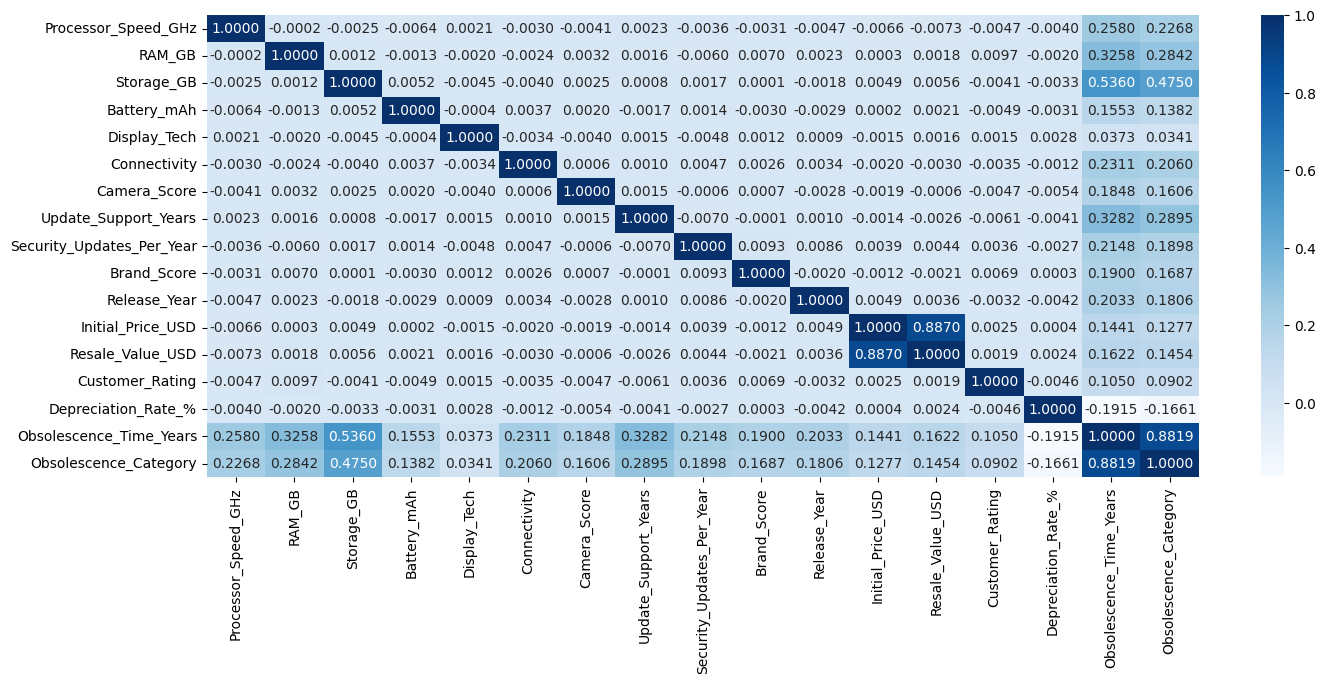

In [12]:
corr = data.corr()

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (16,6))
sns.heatmap(corr, annot = True, fmt = '.4f', cmap = 'Blues')
plt.show()

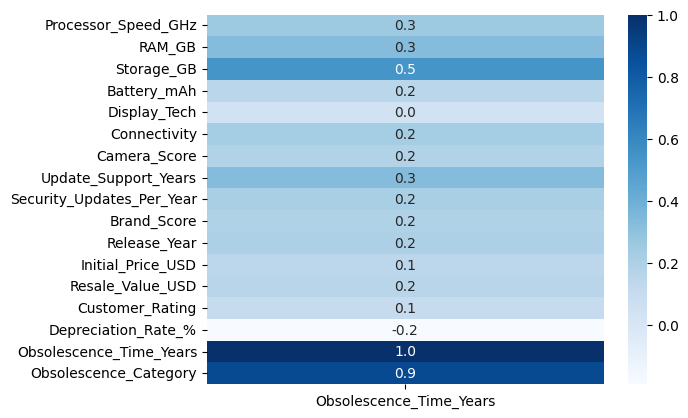

In [13]:
year_corr = data.corr()['Obsolescence_Time_Years']

sns.heatmap(year_corr.to_frame(), annot = True, fmt = '.1f', cmap = 'Blues')
plt.show()